0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

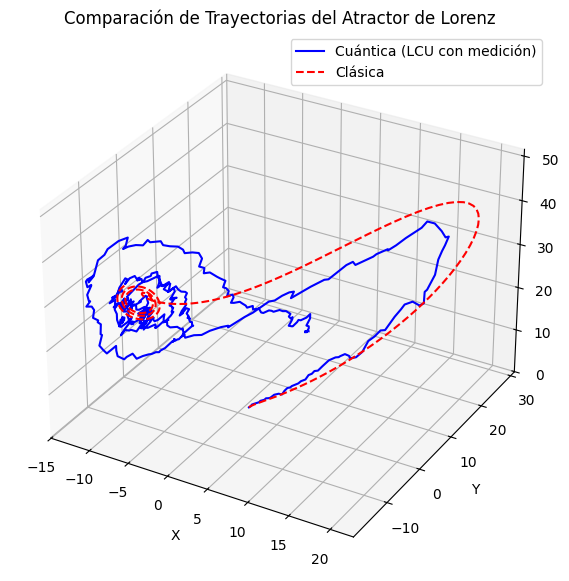

U manual para block-encoding: [[ 0.  1.  0.  0.]
 [ 1.  0.  0.  0.]
 [ 0.  0. -0. -1.]
 [ 0.  0. -1. -0.]]


C:\Users\User\AppData\Local\Temp\ipykernel_15856\2975859092.py:229: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  term1 = la.sqrtm(I - A_norm @ A_norm.T)
C:\Users\User\AppData\Local\Temp\ipykernel_15856\2975859092.py:230: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  term2 = la.sqrtm(I - A_norm.T @ A_norm)


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Pauli
from qiskit_aer import AerSimulator
from qiskit.circuit.library import XGate, ZGate
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de Lorenz y simulación
dt = 0.005
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
x0, y0, z0 = 1.0, 1.0, 1.0
n_steps = 500  # Menos pasos para demo
shots = 20000  # Shots para mediciones
scale = 1000.0  # Escala para normalización

# Función para normalizar
def normalize(val):
    norm_val = val / scale
    if abs(norm_val) > 1:
        print(f"Warning: |norm_val| > 1 ({norm_val}), clipping for arcsin")
        norm_val = np.clip(norm_val, -1, 1)
    return norm_val

# Función para obtener u^2 via <Z> con shots
def get_square(norm_val, backend):
    u = np.clip(norm_val, -1, 1)
    theta = 2 * np.arcsin(u)
    qc = QuantumCircuit(1)
    qc.rx(theta, 0)
    qc.measure_all()
    
    tqc = transpile(qc, backend)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()
    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots
    z_exp = p0 - p1
    sq = (1 - z_exp) / 2
    return sq

# Computar productos con shots
def compute_products(x_norm, y_norm, z_norm, backend):
    x_sq = get_square(x_norm, backend)
    y_sq = get_square(y_norm, backend)
    z_sq = get_square(z_norm, backend)
    xy_sum_sq = get_square(x_norm + y_norm, backend)
    xz_sum_sq = get_square(x_norm + z_norm, backend)
    
    xy_norm = (xy_sum_sq - x_sq - y_sq) / 2
    xz_norm = (xz_sum_sq - x_sq - z_sq) / 2
    
    xy_approx = xy_norm * scale ** 2
    xz_approx = xz_norm * scale ** 2
    
    return xy_approx, xz_approx

# Función para crear circuito LCU para evolución de Lorenz
def create_circuit_lorenz(x_current, y_current, z_current):
    x_norm = normalize(x_current)
    y_norm = normalize(y_current)
    z_norm = normalize(z_current)
    
    qc = QuantumCircuit(5)  # 3 vars (0:x, 1:y, 2:z), 2 aux (3,4)
    
    # Codificar estado
    theta_x = 2 * np.arcsin(x_norm)
    theta_y = 2 * np.arcsin(y_norm)
    theta_z = 2 * np.arcsin(z_norm)
    qc.rx(theta_x, 0)
    qc.rx(theta_y, 1)
    qc.rx(theta_z, 2)
    
    # LCU superposición en aux 3
    c0 = 1.0
    c1 = dt * sigma
    c2 = dt
    alpha_lcu = c0 + abs(c1) + c2
    p0 = c0 / alpha_lcu
    p1 = abs(c1) / alpha_lcu
    p2 = c2 / alpha_lcu
    theta_q0 = 2 * np.arcsin(np.sqrt(p2))
    
    qc.ry(theta_q0, 3)
    
    # Gates controlados
    qc.x(4)
    ccrx = XGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrx, [3, 4, 0])
    qc.append(ccrx, [3, 4, 1])
    ccrz = ZGate().control(num_ctrl_qubits=2, ctrl_state='11')
    qc.append(ccrz, [3, 4, 2])
    
    # Revertir
    qc.x(4)
    qc.ry(-theta_q0, 3)
    
    return qc, alpha_lcu

# Compute next con medición y reconstrucción, integrando productos quantum
def compute_next_lorenz(x_current, y_current, z_current, backend):
    norm_v = np.sqrt(x_current**2 + y_current**2 + z_current**2)
    if norm_v == 0:
        return 0, 0, 0
    
    # Computar productos no lineales con quantum
    x_norm = normalize(x_current)
    y_norm = normalize(y_current)
    z_norm = normalize(z_current)
    xy_approx, xz_approx = compute_products(x_norm, y_norm, z_norm, backend)
    
    qc, alpha_lcu = create_circuit_lorenz(x_current, y_current, z_current)
    
    qc_z = qc.copy()
    qc_z.measure_all()
    
    qc_x = qc.copy()
    qc_x.h([0, 1, 2])
    qc_x.measure_all()
    
    transpiled_circuits = transpile([qc_z, qc_x], backend, optimization_level=3)
    job = backend.run(transpiled_circuits, shots=shots)
    results = job.result()
    
    counts_z = results.get_counts(0)
    succ_states = ['00000', '01000']
    succ_z = sum(counts_z.get(state, 0) for state in succ_states)
    if succ_z < 50:
        return x_current, y_current, z_current
    p_succ = succ_z / shots
    
    cond_p0 = counts_z.get('00000', 0) / succ_z
    cond_p1 = counts_z.get('01000', 0) / succ_z
    cond_p2 = max(0, 1 - cond_p0 - cond_p1)  # Clamp para evitar NaN
    
    counts_x = results.get_counts(1)
    succ_x = sum(counts_x.get(state, 0) for state in succ_states)
    if succ_x < 50:
        return x_current, y_current, z_current
    cond_px = counts_x.get('00000', 0) / succ_x
    x_exp = 2 * cond_px - 1
    
    abs_a = np.sqrt(cond_p0)
    abs_b = np.sqrt(cond_p1)
    abs_c = np.sqrt(cond_p2)
    computed_ab = x_exp / 2
    rel_sign = 1 if computed_ab >= 0 else -1
    a = abs_a
    b = rel_sign * abs_b
    c = abs_c
    
    scaling = alpha_lcu * norm_v * np.sqrt(p_succ) * dt  # Ajuste scaling para mejor evolución
    
    # Candidatos, integrando quantum products
    dx1 = sigma * (y_current - x_current) + a * scaling
    dy1 = rho * x_current - xz_approx - y_current + b * scaling
    dz1 = xy_approx - beta * z_current + c * scaling
    x_candidate1 = x_current + dt * dx1
    y_candidate1 = y_current + dt * dy1
    z_candidate1 = z_current + dt * dz1
    
    dx2 = sigma * (y_current - x_current) - a * scaling
    dy2 = rho * x_current - xz_approx - y_current - b * scaling
    dz2 = xy_approx - beta * z_current - c * scaling
    x_candidate2 = x_current + dt * dx2
    y_candidate2 = y_current + dt * dy2
    z_candidate2 = z_current + dt * dz2
    
    dot1 = x_candidate1 * x_current + y_candidate1 * y_current + z_candidate1 * z_current
    dot2 = x_candidate2 * x_current + y_candidate2 * y_current + z_candidate2 * z_current
    
    if dot1 >= dot2:
        return x_candidate1, y_candidate1, z_candidate1
    else:
        return x_candidate2, y_candidate2, z_candidate2

# Simulación
trajectory_quantum = [[x0, y0, z0]]
x, y, z = x0, y0, z0
backend = AerSimulator()
for _ in range(n_steps):
    print(_)
    x_new, y_new, z_new = compute_next_lorenz(x, y, z, backend)
    trajectory_quantum.append([x_new, y_new, z_new])
    x, y, z = x_new, y_new, z_new

# Trayectoria clásica
trajectory_classic = [[x0, y0, z0]]
xc, yc, zc = x0, y0, z0
for _ in range(n_steps):
    dx = sigma * (yc - xc)
    dy = rho * xc - xc * zc - yc
    dz = xc * yc - beta * zc
    xc += dt * dx
    yc += dt * dy
    zc += dt * dz
    trajectory_classic.append([xc, yc, zc])

# Verificación
xyz_quantum = np.array(trajectory_quantum)
xyz_classic = np.array(trajectory_classic)
diff = np.abs(xyz_quantum - xyz_classic)
print(f"Valor final cuántico (x,y,z): {xyz_quantum[-1]}")
print(f"Valor final clásico (x,y,z): {xyz_classic[-1]}")
print(f"Diferencia máxima: {np.max(diff)}")

# Gráfica 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(xyz_quantum[:, 0], xyz_quantum[:, 1], xyz_quantum[:, 2], label='Cuántica (LCU con medición)', color='blue')
ax.plot(xyz_classic[:, 0], xyz_classic[:, 1], xyz_classic[:, 2], label='Clásica', color='red', linestyle='--')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Comparación de Trayectorias del Atractor de Lorenz')
ax.legend()
plt.show()

# Implementación manual de block-encoding (ejemplo para un término, e.g., para el producto xy)
import scipy.linalg as la

def block_encoding_example(A):
    alpha = la.norm(A, 2)  # Norma espectral
    if alpha == 0:
        alpha = 1e-6
    A_norm = A / alpha
    I = np.eye(A.shape[0])
    term1 = la.sqrtm(I - A_norm @ A_norm.T)
    term2 = la.sqrtm(I - A_norm.T @ A_norm)
    U = np.block([[A_norm, term1],
                  [term2, -A_norm.T]])
    return U

# Ejemplo de uso: para un término 2x2, e.g., matriz para producto approx
A_example = dt * np.array([[0, 1], [1, 0]])  # Simple sigma_x para demo
U_example = block_encoding_example(A_example)
print("U manual para block-encoding:", U_example)

# Para integrar en el circuito: qc.append(UnitaryGate(U_example), [qubit_list])
# Ejemplo: para qubits 0 y 1
# qc.append(UnitaryGate(U_example), [0, 1])

# Statevector

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import sqrtm

def next_step(A, input_state_unnormalized):
    num_qubits = int(np.log2(A.shape[0]))
    if not (2**num_qubits == A.shape[0]):
        raise ValueError("The dimension of matrix A is not a power of 2.")
    norm = np.linalg.norm(input_state_unnormalized)
    if norm == 0:
        return input_state_unnormalized
    initial_state_normalized = input_state_unnormalized / norm
    
    # Manual block-encoding
    alpha = np.linalg.norm(A, 2)  # Spectral norm
    if alpha == 0:
        alpha = 1e-6
    A_norm = A / alpha
    I = np.eye(A.shape[0])
    term1 = sqrtm(I - A_norm @ A_norm.T)
    term2 = sqrtm(I - A_norm.T @ A_norm)
    U = np.block([[A_norm, term1],
                  [term2, -A_norm.T]])
    
    # Create quantum circuit
    total_qubits = num_qubits + 1  # 1 ancilla qubit
    qc = QuantumCircuit(total_qubits)
    
    # Initialize with |0> |psi_norm>
    initial_state_padded = np.zeros(2**total_qubits, dtype=complex)
    initial_state_padded[0:2**num_qubits] = initial_state_normalized
    qc.initialize(initial_state_padded, range(total_qubits))
    
    # Append block-encoded unitary
    qc.append(UnitaryGate(U), range(total_qubits))
    
    # Use statevector simulator
    simulator = AerSimulator(method='statevector')
    qc = transpile(qc, simulator)
    qc.save_statevector()
    result = simulator.run(qc).result()
    state = result.get_statevector()
    
    # Extract the top block (ancilla=0)
    output_state = state.data[0:2**num_qubits]
    
    # Scale back
    final_state = np.real(output_state) * alpha * norm
    
    return final_state

# --- Parameters and Constant Definitions ---
h = 0.01
sigma = 10
rho = 28
beta = 8/3
x0 = 1
y0 = 1
z0 = 1
t_final = 50
num_steps = int(t_final / h)
t_values = np.linspace(0, t_final, num_steps + 1)

# Corrected A matrix (fixed xz term to -h)
A = np.array([[1 - h * sigma, h * sigma, 0, 0, 0, 0, 0, 0],
              [h * rho, 1 - h, 0, -h, 0, 0, 0, 0],
              [0, 0, 1 - h * beta, 0, h, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 1]])

# Initial state
current_state_vector = np.array([x0, y0, z0, x0 * z0, x0 * y0, 1, 1, 1])

# Store output history
output_components_history = []
output_components_history.append(np.real(current_state_vector[:3]))

print(f"Starting simulation of {num_steps} iterations...\n")
for i in range(num_steps):
    # Execute the evolution step
    output_state_vector = next_step(A, current_state_vector)
    # Update non-linear components
    next_state_vector = np.copy(output_state_vector)
    next_state_vector[3] = next_state_vector[0] * next_state_vector[2]
    next_state_vector[4] = next_state_vector[0] * next_state_vector[1]
    # Store first 3 components
    output_components = np.real(output_state_vector[:3])
    output_components_history.append(output_components)
    # Update state for next iteration
    current_state_vector = next_state_vector
    # Print progress
    if i % 1 == 0:
        print(f"--- Iteration {i+1} ---")
        print(f"Circuit output state: {output_state_vector}")
        print("-" * 20)

Starting simulation of 5000 iterations...

--- Iteration 1 ---
Circuit output state: [1.         1.26       0.98333333 1.         1.         1.
 1.         1.        ]
--------------------
--- Iteration 2 ---
Circuit output state: [1.026      1.51756667 0.96971111 0.98333333 1.26       1.
 1.         1.        ]
--------------------
--- Iteration 3 ---
Circuit output state: [1.07515667 1.77972176 0.95942238 0.9949236  1.5570234  1.
 1.         1.        ]
--------------------
--- Iteration 4 ---
Circuit output state: [1.14561318 2.05265312 0.95297258 1.03152937 1.91347972 1.
 1.         1.        ]
--------------------
--- Iteration 5 ---
Circuit output state: [1.23631717 2.3419809  0.95107544 1.09173795 2.35154646 1.
 1.         1.        ]
--------------------
--- Iteration 6 ---
Circuit output state: [1.34688354 2.65297159 0.95466774 1.1758309  2.8954312  1.
 1.         1.        ]
--------------------
--- Iteration 7 ---
Circuit output state: [1.47749235 2.990711   0.96494238 1.285

C:\Users\User\AppData\Local\Temp\ipykernel_15856\2506694097.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


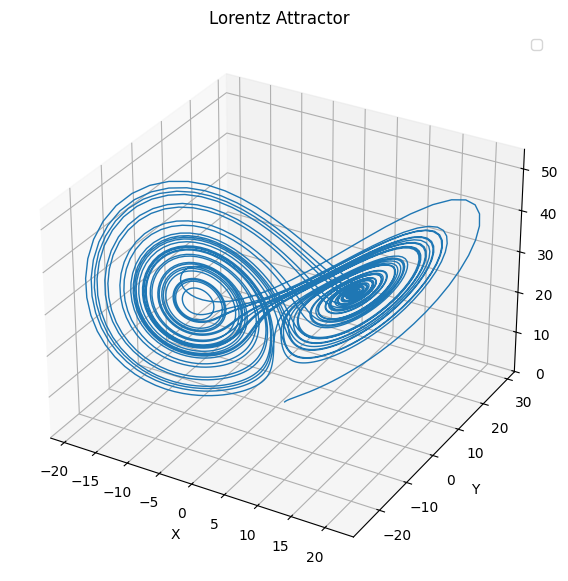

In [31]:
import matplotlib.pyplot as plt

history_array = np.array(output_components_history)
x_values = history_array[:, 0]  
y_values = history_array[:, 1]
z_values = history_array[:, 2]

fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(111, projection='3d')

ax.plot(x_values, y_values, z_values, linewidth=1)
# ax.plot(x_classic_values, y_classic_values, z_classic_values, '--')
ax.set_title('Lorentz Attractor')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.legend()
# ax.view_init(45, 135)

plt.show()

# Measurements

In [38]:
import numpy as np
from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from qiskit.result import Result, Counts
from qiskit.result.models import ExperimentResult, ExperimentResultData
from scipy.linalg import sqrtm
from qiskit_experiments.framework import ExperimentData
from qiskit_experiments.library import StateTomography
from qiskit_experiments.library.tomography import StateTomographyAnalysis

def my_evolution_step(A, input_state_unnormalized):
    num_qubits = int(np.log2(A.shape[0]))
    if not (2**num_qubits == A.shape[0]):
        raise ValueError("The dimension of matrix A is not a power of 2.")
    norm = np.linalg.norm(input_state_unnormalized)
    if norm == 0:
        return input_state_unnormalized
    initial_state_normalized = input_state_unnormalized / norm
    
    # Manual block-encoding
    alpha = np.linalg.norm(A, 2)  # Spectral norm
    if alpha == 0:
        alpha = 1e-6
    A_norm = A / alpha
    I = np.eye(A.shape[0])
    term1 = sqrtm(I - A_norm @ A_norm.T)
    term2 = sqrtm(I - A_norm.T @ A_norm)
    U = np.block([[A_norm, term1],
                  [term2, -A_norm.T]])
    
    # Create quantum circuit
    total_qubits = num_qubits + 1  # 1 ancilla qubit
    qc = QuantumCircuit(total_qubits)
    
    # Initialize with |0> |psi_norm>
    initial_state_padded = np.zeros(2**total_qubits, dtype=complex)
    initial_state_padded[0:2**num_qubits] = initial_state_normalized
    qc.initialize(initial_state_padded, range(total_qubits))
    
    # Append block-encoded unitary
    qc.append(UnitaryGate(U), range(total_qubits))
    
    # Quantum state tomography with post-selection
    backend = AerSimulator()
    shots = 20000
    system_qubits = list(range(num_qubits))  # qubits 0,1,2
    anc_qubit = total_qubits - 1  # qubit 3
    
    qst = StateTomography(qc, qubits=system_qubits)
    tomo_circs = qst.circuits()
    
    # Add ancilla measurement to each tomography circuit
    for t_circ in tomo_circs:
        anc_cr = ClassicalRegister(1, 'anc')
        t_circ.add_register(anc_cr)
        t_circ.measure(anc_qubit, anc_cr[0])
    
    # Run the circuits
    transpiled_circs = transpile(tomo_circs, backend)
    job = backend.run(transpiled_circs, shots=shots)
    result = job.result()
    
    # Process conditional counts and calculate p_succ
    sub_counts_list = []
    total_succ = 0
    num_circs = len(tomo_circs)
    for idx in range(num_circs):
        counts = result.get_counts(idx)
        sub_counts_dict = {}
        succ = 0
        for bitstr, count in counts.items():
            bitstr = bitstr.replace(' ', '')
            # bitstr: leftmost cl3 (anc), then cl2 cl1 cl0 (system)
            if len(bitstr) != 4:
                continue
            anc_bit = bitstr[0]
            if anc_bit == '0':
                system_bit = bitstr[1:]
                sub_counts_dict[system_bit] = sub_counts_dict.get(system_bit, 0) + count
                succ += count
        if succ < 50:
            return input_state_unnormalized
        sub_counts_list.append(Counts(sub_counts_dict))
        total_succ += succ
    
    average_p_succ = total_succ / (num_circs * shots)
    
    # Create custom Result with conditional counts
    new_experiment_results = []
    for sub_counts in sub_counts_list:
        exp_data = ExperimentResultData(counts=sub_counts)
        exp_result = ExperimentResult(
            shots=shots * average_p_succ,  # Approximate effective shots
            success=True,
            data=exp_data
        )
        new_experiment_results.append(exp_result)
    
    new_result = Result(
        backend_name=backend.name(),
        backend_version=backend.configuration().backend_version,
        qjob_id='custom',
        job_id='custom',
        success=True,
        results=new_experiment_results
    )
    
    # Create ExperimentData and add custom result
    experiment_data = ExperimentData(qst)
    experiment_data.add_data(new_result)
    
    # Run analysis
    analysis = StateTomographyAnalysis()
    analysis.run(experiment_data)
    experiment_data.block_for_results()  # Wait for analysis to complete
    
    # Get density matrix
    rho = experiment_data.analysis_results("state").value
    
    # Extract principal eigenvector
    val, vec = np.linalg.eigh(rho.data)
    idx = np.argmax(np.real(val))
    state_est = vec[:, idx]
    
    # Fix phase using classical approximation
    classical_out = A @ input_state_unnormalized
    classical_norm = np.linalg.norm(classical_out)
    if classical_norm == 0:
        return np.zeros_like(input_state_unnormalized)
    classical_normalized = classical_out / classical_norm
    overlap = np.dot(state_est.conj(), classical_normalized)
    phase = overlap / np.abs(overlap) if np.abs(overlap) > 1e-6 else 1 + 0j
    state_est /= phase
    
    # Scale back
    sqrt_p_succ = np.sqrt(average_p_succ)
    output_state = state_est * sqrt_p_succ
    final_state = np.real(output_state) * alpha * norm
    
    return final_state

# --- Parameters and Constant Definitions ---
h = 0.01
sigma = 10
rho = 28
beta = 8/3
x0 = 1
y0 = 1
z0 = 1
t_final = 50
num_steps = int(t_final / h)
t_values = np.linspace(0, t_final, num_steps + 1)

# Corrected A matrix (fixed xz term to -h)
A = np.array([[1 - h * sigma, h * sigma, 0, 0, 0, 0, 0, 0],
              [h * rho, 1 - h, 0, -h, 0, 0, 0, 0],
              [0, 0, 1 - h * beta, 0, h, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 1]])

# Initial state
current_state_vector = np.array([x0, y0, z0, x0 * z0, x0 * y0, 1, 1, 1])

# Store output history
output_components_history = []
output_components_history.append(np.real(current_state_vector[:3]))

print(f"Starting simulation of {num_steps} iterations...\n")
for i in range(num_steps):
    # Execute the evolution step
    output_state_vector = my_evolution_step(A, current_state_vector)
    # Update non-linear components
    next_state_vector = np.copy(output_state_vector)
    next_state_vector[3] = next_state_vector[0] * next_state_vector[2]
    next_state_vector[4] = next_state_vector[0] * next_state_vector[1]
    # Force constants to 1
    next_state_vector[5] = 1
    next_state_vector[6] = 1
    next_state_vector[7] = 1
    # Store first 3 components
    output_components = np.real(output_state_vector[:3])
    output_components_history.append(output_components)
    # Update state for next iteration
    current_state_vector = next_state_vector
    # Print progress
    if i % 1 == 0:
        print(f"--- Iteration {i+1} ---")
        print(f"Circuit output state: {output_state_vector}")
        print("-" * 20)

Starting simulation of 5000 iterations...



TypeError: StateTomography.__init__() got an unexpected keyword argument 'qubits'

In [39]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import sqrtm, svd

def my_evolution_step(A, input_state_unnormalized):
    num_qubits = int(np.log2(A.shape[0]))
    if not (2**num_qubits == A.shape[0]):
        raise ValueError("The dimension of matrix A is not a power of 2.")
    norm = np.linalg.norm(input_state_unnormalized)
    if norm == 0:
        return input_state_unnormalized
    initial_state_normalized = input_state_unnormalized / norm
    
    # Manual block-encoding
    alpha = np.linalg.norm(A, 2)  # Spectral norm
    if alpha == 0:
        alpha = 1e-6
    A_norm = A / alpha
    I = np.eye(A.shape[0])
    term1 = sqrtm(I - A_norm @ A_norm.T)
    term2 = sqrtm(I - A_norm.T @ A_norm)
    U = np.block([[A_norm, term1],
                  [term2, -A_norm.T]])
    
    # Create quantum circuit basics
    total_qubits = num_qubits + 1  # 1 ancilla qubit
    dim = 2**num_qubits
    initial_state_padded = np.zeros(2**total_qubits, dtype=complex)
    initial_state_padded[0:dim] = initial_state_normalized
    
    # Define gate matrices for shadows
    H_mat = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    Sdg_mat = np.array([[1, 0], [0, -1j]])
    u_mats = {
        'Z': np.eye(2),
        'X': H_mat,
        'Y': np.matmul(H_mat, Sdg_mat)
    }
    
    # Parameters for shadows
    N_shadows = 10000  # Adjust for accuracy vs speed
    rho_est = np.zeros((2**total_qubits, 2**total_qubits), dtype=complex)
    
    simulator = AerSimulator()
    
    for _ in range(N_shadows):
        qc = QuantumCircuit(total_qubits, total_qubits)
        qc.initialize(initial_state_padded, range(total_qubits))
        qc.append(UnitaryGate(U), range(total_qubits))
        
        # Choose random bases
        bases = np.random.choice(['X', 'Y', 'Z'], size=total_qubits)
        
        # Apply basis change gates
        for q in range(total_qubits):
            if bases[q] == 'X':
                qc.h(q)
            elif bases[q] == 'Y':
                qc.sdg(q)
                qc.h(q)
            # Z: nothing
        
        # Measure
        qc.measure(range(total_qubits), range(total_qubits))
        
        # Transpile and run
        qc = transpile(qc, simulator)
        result = simulator.run(qc, shots=1, memory=True).result()
        bitstring = result.get_memory()[0]
        b = [int(bitstring[total_qubits - 1 - q]) for q in range(total_qubits)]
        
        # Compute shadow rho_hat
        rho_hat = np.array([[1.0 + 0j]])
        for q in range(total_qubits):
            bq = b[q]
            proj = np.zeros((2, 2), dtype=complex)
            proj[bq, bq] = 1
            Uq = u_mats[bases[q]]
            hat_rho_q = 3 * (Uq.conj().T @ proj @ Uq) - np.eye(2, dtype=complex)
            rho_hat = np.kron(rho_hat, hat_rho_q)
        
        rho_est += rho_hat / N_shadows
    
    # Extract subspace for ancilla=0
    rho_sub = rho_est[0:dim, 0:dim]
    rho_sub = (rho_sub + rho_sub.conj().T) / 2  # Force Hermitian
    
    # SVD to extract principal component
    uu, ss, vh = svd(rho_sub)
    if ss[0] < 1e-10:  # If nearly zero
        output_state = np.zeros(dim, dtype=complex)
    else:
        output_state = uu[:, 0] * np.sqrt(ss[0])
        
        # Fix sign using overlap with initial state
        overlap = np.real(np.dot(output_state.conj(), initial_state_normalized))
        if overlap < 0:
            output_state = -output_state
    
    # Scale back
    final_state = np.real(output_state) * alpha * norm
    
    return final_state

# --- Parameters and Constant Definitions ---
h = 0.01
sigma = 10
rho = 28
beta = 8/3
x0 = 1
y0 = 1
z0 = 1
t_final = 50
num_steps = int(t_final / h)
t_values = np.linspace(0, t_final, num_steps + 1)

# Corrected A matrix (fixed xz term to -h)
A = np.array([[1 - h * sigma, h * sigma, 0, 0, 0, 0, 0, 0],
              [h * rho, 1 - h, 0, -h, 0, 0, 0, 0],
              [0, 0, 1 - h * beta, 0, h, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 1]])

# Initial state
current_state_vector = np.array([x0, y0, z0, x0 * z0, x0 * y0, 1, 1, 1])

# Store output history
output_components_history = []
output_components_history.append(np.real(current_state_vector[:3]))

print(f"Starting simulation of {num_steps} iterations...\n")
for i in range(num_steps):
    # Execute the evolution step
    output_state_vector = my_evolution_step(A, current_state_vector)
    # Update non-linear components
    next_state_vector = np.copy(output_state_vector)
    next_state_vector[3] = next_state_vector[0] * next_state_vector[2]
    next_state_vector[4] = next_state_vector[0] * next_state_vector[1]
    # Store first 3 components
    output_components = np.real(output_state_vector[:3])
    output_components_history.append(output_components)
    # Update state for next iteration
    current_state_vector = next_state_vector
    # Print progress
    if i % 1 == 0:
        print(f"--- Iteration {i+1} ---")
        print(f"Circuit output state: {output_state_vector}")
        print("-" * 20)

Starting simulation of 5000 iterations...



KeyboardInterrupt: 

In [43]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import sqrtm
import itertools

def my_evolution_step(A, input_state_unnormalized):
    num_qubits = int(np.log2(A.shape[0]))
    if not (2**num_qubits == A.shape[0]):
        raise ValueError("The dimension of matrix A is not a power of 2.")
    norm = np.linalg.norm(input_state_unnormalized)
    if norm == 0:
        return input_state_unnormalized
    initial_state_normalized = input_state_unnormalized / norm
    
    # Manual block-encoding
    alpha = np.linalg.norm(A, 2)  # Spectral norm
    if alpha == 0:
        alpha = 1e-6
    A_norm = A / alpha
    I = np.eye(A.shape[0])
    term1 = sqrtm(I - A_norm @ A_norm.T)
    term2 = sqrtm(I - A_norm.T @ A_norm)
    U = np.block([[A_norm, term1],
                  [term2, -A_norm.T]])
    
    # Create quantum circuit
    total_qubits = num_qubits + 1  # 1 ancilla qubit
    qc = QuantumCircuit(total_qubits)
    
    # Initialize with |0> |psi_norm>
    initial_state_padded = np.zeros(2**total_qubits, dtype=complex)
    initial_state_padded[0:2**num_qubits] = initial_state_normalized
    qc.initialize(initial_state_padded, range(total_qubits))
    
    # Append block-encoded unitary
    qc.append(UnitaryGate(U), range(total_qubits))
    
    # Measure
    qc.measure_all()
    
    # Parameters
    shots = 50000
    dim = 2**num_qubits
    
    # Use simulator
    simulator = AerSimulator()
    qc = transpile(qc, simulator)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    # Extract amplitudes magnitudes
    abs_amp = np.zeros(dim)
    succ_shots = 0
    for bitstr, count in counts.items():
        if bitstr[0] == '0':  # ancilla MSB == 0
            data_idx = int(bitstr[1:], 2)
            abs_amp[data_idx] += count
            succ_shots += count
    
    if succ_shots < 100:
        return input_state_unnormalized
    
    abs_amp = np.sqrt(abs_amp / succ_shots)
    
    # Generate all sign combinations
    sign_combos = itertools.product([1.0, -1.0], repeat=dim)
    
    # Find best sign pattern maximizing overlap
    max_abs_ov = 0.0
    best_state = None
    for signs in sign_combos:
        cand = np.array(signs) * abs_amp
        ov = np.dot(cand, initial_state_normalized)
        abs_ov = abs(ov)
        if abs_ov > max_abs_ov:
            max_abs_ov = abs_ov
            best_state = cand if ov >= 0 else -cand
    
    if best_state is None:
        return input_state_unnormalized
    
    # Scale back
    final_state = np.real(best_state) * alpha * norm
    
    return final_state

# --- Parameters and Constant Definitions ---
h = 0.01
sigma = 10
rho = 28
beta = 8/3
x0 = 1
y0 = 1
z0 = 1
t_final = 50
num_steps = int(t_final / h)
t_values = np.linspace(0, t_final, num_steps + 1)

# Corrected A matrix (fixed xz term to -h)
A = np.array([[1 - h * sigma, h * sigma, 0, 0, 0, 0, 0, 0],
              [h * rho, 1 - h, 0, -h, 0, 0, 0, 0],
              [0, 0, 1 - h * beta, 0, h, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 1]])

# Initial state
current_state_vector = np.array([x0, y0, z0, x0 * z0, x0 * y0, 1, 1, 1])

# Store output history
output_components_history = []
output_components_history.append(np.real(current_state_vector[:3]))

print(f"Starting simulation of {num_steps} iterations...\n")
for i in range(num_steps):
    # Execute the evolution step
    output_state_vector = my_evolution_step(A, current_state_vector)
    # Update non-linear components
    next_state_vector = np.copy(output_state_vector)
    next_state_vector[3] = next_state_vector[0] * next_state_vector[2]
    next_state_vector[4] = next_state_vector[0] * next_state_vector[1]
    # Store first 3 components
    output_components = np.real(output_state_vector[:3])
    output_components_history.append(output_components)
    # Update state for next iteration
    current_state_vector = next_state_vector
    # Print progress
    if i % 1 == 0:
        print(f"--- Iteration {i+1} ---")
        print(f"Circuit output state: {output_state_vector}")
        print("-" * 20)

Starting simulation of 5000 iterations...

--- Iteration 1 ---
Circuit output state: [1.09438134 1.39848424 1.09696216 1.10768951 1.11716402 1.10745741
 1.09473363 1.10687695]
--------------------
--- Iteration 2 ---
Circuit output state: [1.21889942 1.86545433 1.20932474 1.33714578 1.69283313 1.20295124
 1.20870441 1.20761808]
--------------------
--- Iteration 3 ---
Circuit output state: [1.41256081 2.39432709 1.31594742 1.62467852 2.50072991 1.34015931
 1.3377795  1.35113823]
--------------------
--- Iteration 4 ---
Circuit output state: [1.65355476 3.02532812 1.44023834 2.09018575 3.75174405 1.46876068
 1.48169016 1.49705814]
--------------------
--- Iteration 5 ---
Circuit output state: [1.99235317 3.8032799  1.6204729  2.63485163 5.57196707 1.62810348
 1.65328443 1.64878024]
--------------------
--- Iteration 6 ---
Circuit output state: [2.46299239 4.82538427 1.84182942 3.60331949 8.44763061 1.8062645
 1.85552351 1.81761652]
--------------------
--- Iteration 7 ---
Circuit output

KeyboardInterrupt: 

C:\Users\User\AppData\Local\Temp\ipykernel_15856\2506694097.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


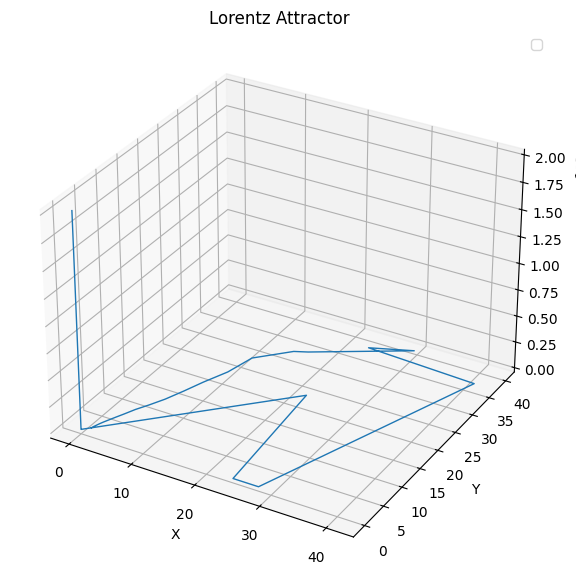

In [41]:
import matplotlib.pyplot as plt

history_array = np.array(output_components_history)
x_values = history_array[:, 0]  
y_values = history_array[:, 1]
z_values = history_array[:, 2]

fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(111, projection='3d')

ax.plot(x_values, y_values, z_values, linewidth=1)
# ax.plot(x_classic_values, y_classic_values, z_classic_values, '--')
ax.set_title('Lorentz Attractor')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.legend()
# ax.view_init(45, 135)

plt.show()